In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astroquery.gaia import Gaia
import matplotlib as mpl
mpl.rcdefaults()  
plt.rcParams['text.usetex'] = True
from dustmaps.bayestar import BayestarQuery
from astropy.coordinates import SkyCoord
import astropy.units as u
bayestar = BayestarQuery(version='bayestar2019')
from cmcrameri import cm
from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata
from matplotlib.ticker import FixedLocator
from matplotlib.lines import Line2D

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 25.961 s
  pix_info:   0.420 s
   samples:  14.980 s
      best:   2.988 s
       nan:   0.077 s
      sort:   7.438 s
       idx:   0.058 s


In [244]:
# Solar reference values
NUMAX_SUN = 3090.0  # μHz
TEFF_SUN = 5777.0   # K
LOGG_SUN = 4.44     
G_SUN = 27420
M_SUN = 1.989*10**30  #kg
DNU_SUN = 135.1  # μHz
LOGG_SUN  = 4.438

In [245]:
def numax_to_logg(numax, Teff):
    """Scaling relation: logg from numax at a fixed Teff."""
    return LOGG_SUN + np.log10(numax / NUMAX_SUN) + 0.5 * np.log10(Teff / TEFF_SUN)

def logg_to_numax(logg, Teff):
    """Inverse: numax from logg at a fixed Teff."""
    return NUMAX_SUN * 10**(logg - LOGG_SUN - 0.5 * np.log10(Teff / TEFF_SUN))

In [246]:
#read in one solution
one_solution = pd.read_csv("../data/true_one_solution.csv",dtype={'source_id':str})

#SED results
sed_results = pd.read_csv('../data/sed_results.csv',dtype={'source_id':str})

In [247]:
sed_results = sed_results.drop_duplicates(subset='source_id', keep='first')

In [248]:
len(one_solution)

2615

In [249]:
#merge
one_solution = one_solution.merge(sed_results,on='source_id',how='left')
#isolate stars with missing SED results
unconfirmed = one_solution[one_solution['Teff'].isna()]
one_solution = one_solution[~one_solution['Teff'].isna()]

In [250]:
len(one_solution)

2578

In [251]:
parallax_problem = one_solution[one_solution['parallax'] / one_solution['parallax_error'] < 1] # 64 stars with error > 100pc, 30 stars with negative parallax
good_parallax = one_solution[one_solution['parallax'] / one_solution['parallax_error'] >= 1]

In [252]:
len(good_parallax)

2482

In [253]:
#deal with stars with good parallax first
# distance from parallax
good_parallax['distance_pc'] = 1000 / good_parallax['parallax']

coords = SkyCoord(
    ra=good_parallax['ra'].values * u.deg,
    dec=good_parallax['dec'].values * u.deg,
    distance=good_parallax['distance_pc'].values * u.pc
)

# BAYESTAR returns reddening on its own scale — need mode='best' or samples
good_parallax['E_bayestar'] = bayestar(coords, mode='best')

E_BV = 0.884 * good_parallax['E_bayestar']
#convert to reddening in G band
good_parallax['A_G'] =  2.74* E_BV

# extinction-corrected apparent magnitude
good_parallax['G_corrected'] = good_parallax['phot_g_mean_mag'] - good_parallax['A_G']

# now redo the earlier steps with G_corrected instead of phot_g_mean_mag
good_parallax['abs_mag'] = good_parallax['G_corrected'] + 5 * np.log10(good_parallax['parallax']) - 10

# --- error propagation ---
# magnitude error from flux error: sigma_mag = (2.5 / ln10) * (flux_error / flux)
good_parallax['mag_error'] = (2.5 / np.log(10)) * (good_parallax['phot_g_mean_flux_error'] / good_parallax['phot_g_mean_flux'])

# parallax contributes to abs_mag error via d(abs_mag)/d(parallax) = 5/(parallax * ln10)
good_parallax['parallax_mag_error'] = (5 / np.log(10)) * (good_parallax['parallax_error'] / good_parallax['parallax'])

good_parallax['A_G_error'] = 0.15 * good_parallax['A_G']  # rough approximation

good_parallax['abs_mag_error'] = np.sqrt(
    good_parallax['mag_error']**2 +
    good_parallax['parallax_mag_error']**2 +
    good_parallax['A_G_error']**2
)

/var/folders/kj/qbnn_d_10sz_s6gyn25kdtrw0000gp/T/ipykernel_21510/3430789958.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_parallax['distance_pc'] = 1000 / good_parallax['parallax']
/var/folders/kj/qbnn_d_10sz_s6gyn25kdtrw0000gp/T/ipykernel_21510/3430789958.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_parallax['E_bayestar'] = bayestar(coords, mode='best')
/var/folders/kj/qbnn_d_10sz_s6gyn25kdtrw0000gp/T/ipykernel_21510/3430789958.py:16: SettingWithCopyWarning: 
A value is trying to be

In [254]:
# ok now stars with bad parallax
source_ids = parallax_problem['source_id']  # your list

id_list = ",".join(str(s) for s in source_ids)

query = f"""
SELECT g.source_id, g.ra, g.dec, g.parallax,
       bj.r_med_geo, bj.r_lo_geo, bj.r_hi_geo,
       bj.r_med_photogeo, bj.r_lo_photogeo, bj.r_hi_photogeo
FROM gaiadr3.gaia_source AS g
JOIN external.gaiaedr3_distance AS bj
  ON g.source_id = bj.source_id
WHERE g.source_id IN ({id_list})
"""

job = Gaia.launch_job_async(query)
results = job.get_results().to_pandas()
results['source_id'] = results['source_id'].astype(str)

results['r_unc'] = (results['r_hi_photogeo'] - results['r_lo_photogeo']) / 2 #uncertainty = 1/2 range
parallax_problem = parallax_problem.merge(results[['source_id','r_med_photogeo','r_unc']], on='source_id', how='left')

INFO: Query finished. [astroquery.utils.tap.core]


In [255]:
coords = SkyCoord(
    ra=parallax_problem['ra'].values * u.deg,
    dec=parallax_problem['dec'].values * u.deg,
    distance=parallax_problem['r_med_photogeo'].values * u.pc
)

# BAYESTAR returns reddening on its own scale — need mode='best' or samples
parallax_problem['E_bayestar'] = bayestar(coords, mode='best')

E_BV = 0.884 * parallax_problem['E_bayestar']

parallax_problem['A_G'] =  2.74* E_BV

# extinction-corrected apparent magnitude
parallax_problem['G_corrected'] = parallax_problem['phot_g_mean_mag'] - parallax_problem['A_G']

# now redo the earlier steps with G_corrected instead of phot_g_mean_mag
parallax_problem['abs_mag'] = parallax_problem['G_corrected'] - 5 * np.log10(parallax_problem['r_med_photogeo']) + 5


# --- error propagation ---
# magnitude error from flux error: sigma_mag = (2.5 / ln10) * (flux_error / flux)
parallax_problem['mag_error'] = (2.5 / np.log(10)) * (parallax_problem['phot_g_mean_flux_error'] / parallax_problem['phot_g_mean_flux'])

parallax_problem['distance_mag_error'] = (5 / (parallax_problem['r_med_photogeo'] * np.log(10))) * parallax_problem['r_unc']

parallax_problem['A_G_error'] = 0.15 * parallax_problem['A_G']  # rough approximation

parallax_problem['abs_mag_error'] = np.sqrt(
    parallax_problem['mag_error']**2 +
    parallax_problem['distance_mag_error']**2 +
    parallax_problem['A_G_error']**2
)

In [256]:
# Stack the two lookup tables, giving good_parallax priority when a source_id appears in both
parallax_stack = pd.concat([
    parallax_problem[['source_id', 'abs_mag', 'abs_mag_error']],
    good_parallax[['source_id', 'abs_mag', 'abs_mag_error']]
])

one_solution = one_solution.merge(parallax_stack, on='source_id', how='left')


In [257]:
# line endpoints: (Teff1, mag1) = (6800, -2), (Teff2, mag2) = (3400, 7)
teff1, mag1 = 6800, -2
teff2, mag2 = 3400, 7

slope = (mag2 - mag1) / (teff2 - teff1)
intercept = mag1 - slope * teff1

def line_mag(teff):
    return slope * teff + intercept

# "below" the line visually (inverted y-axis) means abs_mag is LARGER than the line value
below_line = one_solution[one_solution['abs_mag'] > line_mag(one_solution['Teff'])].copy()
above_line = one_solution[one_solution['abs_mag'] <= line_mag(one_solution['Teff'])].copy()


In [258]:
rg_ms = pd.read_csv('../data/ms_true_sources.csv')

In [259]:
above_line = pd.concat([above_line, rg_ms])

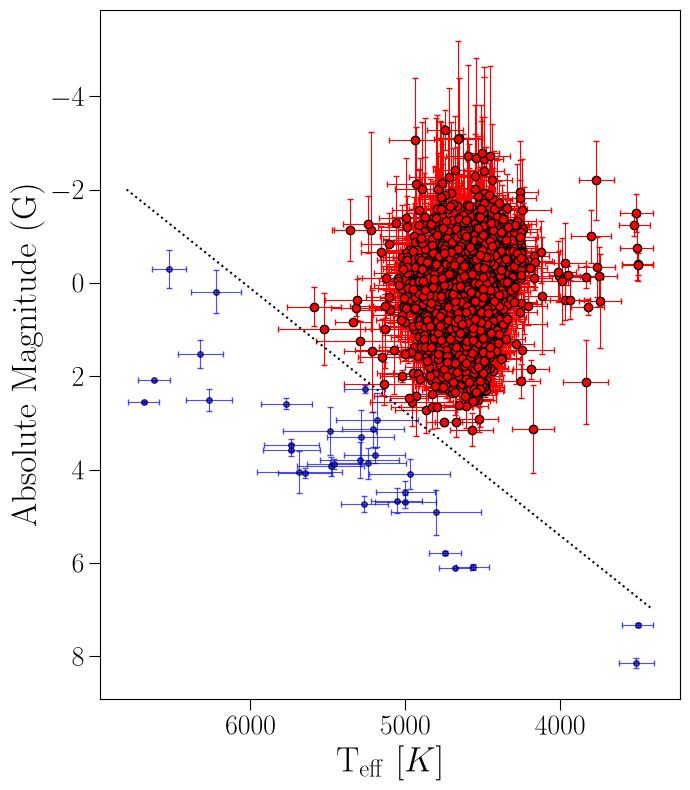

In [260]:
# line endpoints: (Teff1, mag1) = (6800, -2), (Teff2, mag2) = (3400, 7)
teff1, mag1 = 6800, -2
teff2, mag2 = 3400, 7
slope = (mag2 - mag1) / (teff2 - teff1)
intercept = mag1 - slope * teff1

def line_mag(teff):
    return slope * teff + intercept


fig, ax = plt.subplots(figsize=(7, 8))

# ── Primary plot ────────────────────────────────────────────────────────────
ax.errorbar(
    above_line['Teff'], above_line['abs_mag'],
    xerr=above_line['s_Teff'], yerr=above_line['abs_mag_error'],
    fmt='o', c='red', markeredgecolor='black',
    linewidth=0.4, elinewidth=0.8, capsize=2,
    label=r'$\mathrm{RG}$', rasterized=True
)
ax.errorbar(
    below_line['Teff'], below_line['abs_mag'],
    xerr=below_line['s_Teff'], yerr=below_line['abs_mag_error'],
    fmt='o', c='blue', markeredgecolor='black',
    linewidth=0.4, elinewidth=0.8, capsize=2,
    ms=4, alpha=0.7,
    label=r'$\mathrm{MS}$', rasterized=True
)

ax.invert_xaxis()
ax.invert_yaxis()

ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=8)
ax.tick_params(axis='both', which='minor', labelsize=20, direction='out', length=4)

ax.set_xlabel(r'$\mathrm{T_{eff}} \, \, [K]$', fontsize=25)
ax.set_ylabel(r'$\mathrm{Absolute \,\, Magnitude \,\, (G)}$', fontsize=25)

ax.plot([6800, 3400], [-2, 7], color='black', linewidth=1.5, linestyle=':')

plt.tight_layout()
plt.savefig('../../figures/hr_diagram_select_RG.png', bbox_inches='tight')
plt.show()

In [261]:
rg = above_line.copy()

In [262]:
###fiducial line at the cool edge of the plot
# Define the line endpoints
x1, y1 = 4450, 300
x2, y2 = 4100, 3

# Slope in log(numax) vs Teff space
m = (np.log10(y2) - np.log10(y1)) / (x2 - x1)

# For each star, compute the line's log(numax) at its Teff
log_numax_line = np.log10(y1) + m * (rg['Teff'] - x1)

# Compare log(numax) of each star to the line
log_numax_stars = np.log10(rg['numax'])

weird = rg[log_numax_stars > log_numax_line]  #cooler than fiducial (28 stars)
rg = rg[log_numax_stars < log_numax_line]  #warmer than fiducial

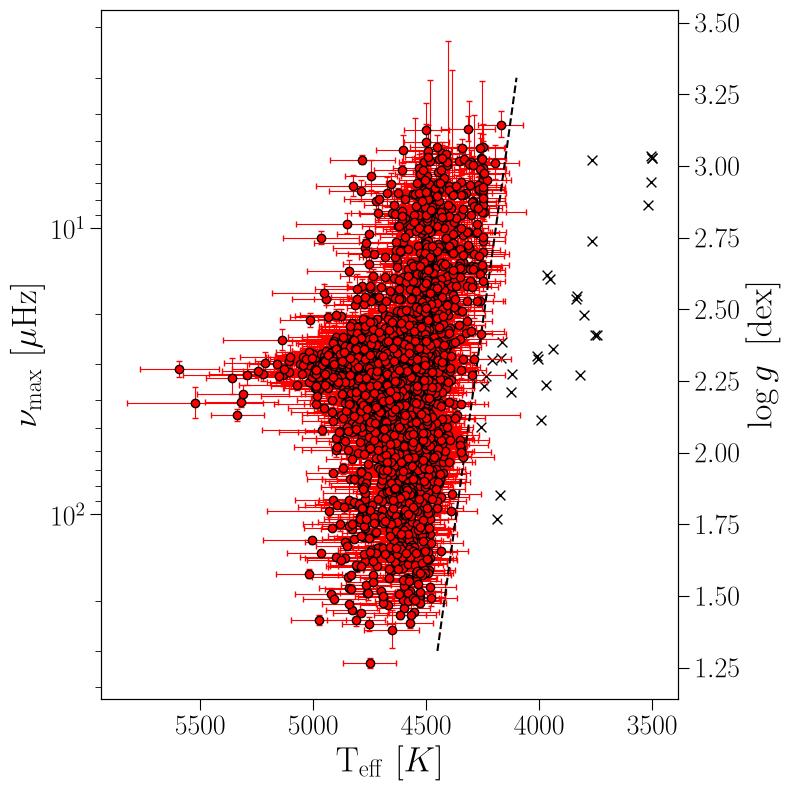

In [263]:
Teff_ref  = np.median(rg['Teff'])

fig, ax = plt.subplots(figsize=(8, 8))

# ── Primary plot ────────────────────────────────────────────────────────────
ax.errorbar(rg['Teff'], rg['numax'], 
             xerr=rg['s_Teff'],yerr=rg['numax_sig'],
             fmt='o', c='red', markeredgecolor='black', 
             linewidth=0.4, elinewidth=0.8, capsize=2,
             label="$\mathrm{RG \,\,from \,\,Ciardi \,\,2011}$",rasterized=True)

ax.set_yscale('log')
ax.invert_yaxis()
ax.invert_xaxis()
ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=8)
ax.tick_params(axis='y', which='minor', labelsize=20, direction='out', length=4)
ax.set_xlabel(r'$\mathrm{T_{eff}} \, \, [K]$', fontsize=25)
ax.set_ylabel(r'$\nu_{\mathrm{max}} \mathrm{\, \, [\mu Hz]}$', fontsize=25)
ax.plot([4450, 4100], [300, 3], color='black', linewidth=1.5, linestyle='--')
ax.scatter(weird['Teff'], weird['numax'], marker='x',color='black', linewidth=1, s=50, rasterized=True)

# ── Secondary (right) log g axis ────────────────────────────────────────────
ax2 = ax.twinx()

# Mirror the primary y-limits so the two axes stay in sync
ylo, yhi = ax.get_ylim()  # numax limits (inverted)
ax2.set_ylim(numax_to_logg(ylo,Teff_ref), numax_to_logg(yhi,Teff_ref))
ax2.invert_yaxis()  # keep same orientation

# Choose round logg tick positions that fall within the numax range
numax_lo, numax_hi = sorted([ylo, yhi])  # actual min/max in data coords
logg_lo = numax_to_logg(numax_lo,Teff_ref)
logg_hi = numax_to_logg(numax_hi,Teff_ref)
logg_ticks = np.arange(np.ceil(logg_lo * 4) / 4,  # round to nearest 0.25
                       np.floor(logg_hi * 4) / 4 + 0.01, 0.25)
# Keep only ticks that sit inside the plotted numax range
logg_ticks = logg_ticks[(logg_ticks >= logg_lo) & (logg_ticks <= logg_hi)]

ax2.set_yticks(logg_ticks)
ax2.set_yticklabels([f'${v:.2f}$' for v in logg_ticks], fontsize=20)
ax2.tick_params(axis='y', which='both', direction='out', labelsize=20, length=8)
ax2.set_ylabel(r'$\log g \;\; [\mathrm{dex}]$', fontsize=25)

plt.tight_layout()
plt.savefig('../figures/hr_rg_err.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

/var/folders/kj/qbnn_d_10sz_s6gyn25kdtrw0000gp/T/ipykernel_21510/3490937458.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


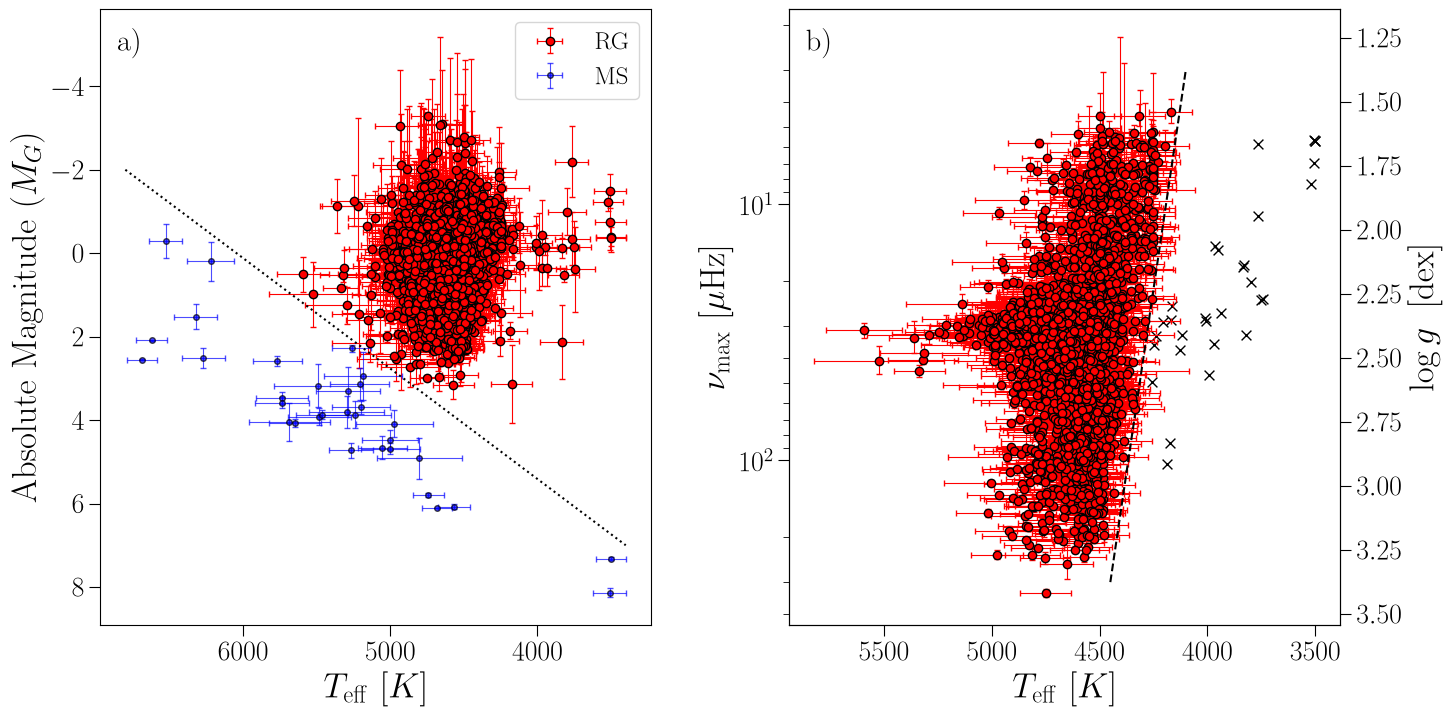

In [264]:
# line endpoints: (Teff1, mag1) = (6800, -2), (Teff2, mag2) = (3400, 7)
teff1, mag1 = 6800, -2
teff2, mag2 = 3400, 7
slope = (mag2 - mag1) / (teff2 - teff1)
intercept = mag1 - slope * teff1

def line_mag(teff):
    return slope * teff + intercept

Teff_ref = np.median(rg['Teff'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'wspace': 0.25})

# ── Left panel: HR diagram (Teff vs abs mag) ────────────────────────────────
ax1.errorbar(
    above_line['Teff'], above_line['abs_mag'],
    xerr=above_line['s_Teff'], yerr=above_line['abs_mag_error'],
    fmt='o', c='red', markeredgecolor='black',
    linewidth=0.4, elinewidth=0.8, capsize=2,
    label=r'$\mathrm{RG}$', rasterized=True
)
ax1.errorbar(
    below_line['Teff'], below_line['abs_mag'],
    xerr=below_line['s_Teff'], yerr=below_line['abs_mag_error'],
    fmt='o', c='blue', markeredgecolor='black',
    linewidth=0.4, elinewidth=0.8, capsize=2,
    ms=4, alpha=0.7,
    label=r'$\mathrm{MS}$', rasterized=True
)

ax1.invert_xaxis()
ax1.invert_yaxis()

ax1.tick_params(axis='both', which='major', labelsize=20, direction='out', length=8)
ax1.tick_params(axis='both', which='minor', labelsize=20, direction='out', length=4)

ax1.set_xlabel(r'$T_{\mathrm{eff}} \, \, [K]$', fontsize=25)
ax1.set_ylabel(r'$\mathrm{Absolute \,\, Magnitude \,\,} (M_G)$', fontsize=25)

ax1.plot([6800, 3400], [-2, 7], color='black', linewidth=1.5, linestyle=':')
ax1.legend(fontsize=18)

ax1.text(0.03, 0.97, r'$\mathrm{a)}$', transform=ax1.transAxes,
          fontsize=22, va='top', ha='left')

# ── Right panel: Teff vs numax, with secondary log g axis ──────────────────
#isolate stars to right of fiducial line
rg = rg[~rg['source_id'].isin(weird['source_id'])]

ax2.errorbar(
    rg['Teff'], rg['numax'],
    xerr=rg['s_Teff'], yerr=rg['numax_sig'],
    fmt='o', c='red', markeredgecolor='black',
    linewidth=0.4, elinewidth=0.8, capsize=2,
    label=r'$\mathrm{RG \,\,from \,\,Ciardi \,\,2011}$', rasterized=True
)
ax2.set_yscale('log')
ax2.invert_yaxis()
ax2.invert_xaxis()

ax2.tick_params(axis='both', which='major', labelsize=20, direction='out', length=8)
ax2.tick_params(axis='y', which='minor', labelsize=20, direction='out', length=4)

ax2.set_xlabel(r'$T_{\mathrm{eff}} \, \, [K]$', fontsize=25)
ax2.set_ylabel(r'$\nu_{\mathrm{max}} \mathrm{\, \, [\mu Hz]}$', fontsize=25)

ax2.plot([4450, 4100], [300, 3], color='black', linewidth=1.5, linestyle='--')
ax2.scatter(weird['Teff'], weird['numax'], marker='x', color='black', linewidth=1, s=50, rasterized=True)

ax2.text(0.03, 0.97, r'$\mathrm{b)}$', transform=ax2.transAxes,
          fontsize=22, va='top', ha='left')

# ── Secondary (right) log g axis on ax2 ─────────────────────────────────────
ax2b = ax2.twinx()

# Mirror the primary y-limits so the two axes stay in sync
ylo, yhi = ax2.get_ylim()  # numax limits (inverted)
ax2b.set_ylim(numax_to_logg(ylo, Teff_ref), numax_to_logg(yhi, Teff_ref))

# Choose round logg tick positions that fall within the numax range
numax_lo, numax_hi = sorted([ylo, yhi])  # actual min/max in data coords
logg_lo = numax_to_logg(numax_lo, Teff_ref)
logg_hi = numax_to_logg(numax_hi, Teff_ref)
logg_ticks = np.arange(np.ceil(logg_lo * 4) / 4,  # round to nearest 0.25
                        np.floor(logg_hi * 4) / 4 + 0.01, 0.25)

# Keep only ticks that sit inside the plotted numax range
logg_ticks = logg_ticks[(logg_ticks >= logg_lo) & (logg_ticks <= logg_hi)]
ax2b.set_yticks(logg_ticks)
ax2b.set_yticklabels([f'${v:.2f}$' for v in logg_ticks], fontsize=20)
ax2b.tick_params(axis='y', which='both', direction='out', labelsize=20, length=8)
ax2b.set_ylabel(r'$\log g \;\; [\mathrm{dex}]$', fontsize=25)

plt.tight_layout()
plt.savefig('../figures/hr_diagram_combined.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [265]:
above_line.to_csv('../data/above_line.csv', index=False)
below_line.to_csv('../data/below_line.csv', index=False)

In [266]:
weird.to_csv('../data/right_of_fiducial.csv', index=False)

In [267]:
rg.to_csv('../data/true_sources_final.csv',index=False)

In [268]:
new_unconfirmed = pd.concat([unconfirmed,weird])

In [269]:
#read in one solution
one_solution = pd.read_csv("../data/true_one_solution.csv",dtype={'source_id':str})

In [272]:
new_unconfirmed[new_unconfirmed['source_id'].isin(one_solution['source_id'])].to_csv('../data/unconfirmed.csv', index=False) 